Ô này dùng để thiết lập tài khoản Kaggle trong Colab. Nó tạo một thư mục .kaggle, sau đó lưu access_token vào một tệp trong thư mục đó và đặt quyền truy cập để chỉ mình t mới có thể đọc được tệp đó. Điều này cho phép tải xuống các bộ dữ liệu từ Kaggle trực tiếp trong Colab.

In [ ]:
!mkdir -p ~/.kaggle
!echo KGAT_aade15e49b0b38b5b0297eaa2b4690b3 > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token

In [2]:
import pandas as pd
# thư viện này dùng để tìm các tệp và thư mục theo 1 mẫu đc chỉ định (vd tất cả các tệp có đuôi .jpg)
import glob
# module này cung cấp cách để tương tác với hdh như truy cập vào thư mục, đường dẫn tệp
import os

print("\nKẾT QUẢ EDA DATASET 1: E-COMMERCE)")

# quét tìm và đếm tổng số lượng ảnh (jpg, png) trong thư mục hiện tại và thư mục con (recursive=True)
image_files = glob.glob('**/*.jpg', recursive=True) + glob.glob('**/*.png', recursive=True) + glob.glob('**/*.jpeg', recursive=True)
print(f"Tổng số lượng ảnh tìm thấy: {len(image_files)} ảnh")

# quét sâu tìm file CSV ở mọi thư mục con
csv_files = glob.glob('**/*.csv', recursive=True)

if csv_files:
    print(f"\nFile data: {csv_files[0]}")
    # dòng này đọc tệp csv đầu tiên đã tìm thấy 1 dataframe của pandas và skip các dòng lỗi
    df1 = pd.read_csv(csv_files[0], on_bad_lines='skip')
    print(f"Tổng số mẫu/dòng: {df1.shape[0]}")
    print(f"Các trường dữ liệu/cột: {df1.shape[1]}")
    print("\nChi tiết các trường:")
    # in ra tóm tát các thông tin về dataframe df1 bao gồm kiểu dữ liệu của từng cột,
    # số lượng giá trị k rỗng, mức sử dụng bộ nhớ
    print(df1.info())
    print("\nVấn đề chất lượng / số lượng dữ liệu trống ở mỗi cột:")
    # dòng này tính tổng số lượng giá trị rỗng cho mỗi cột, df1.null() trẩ về 1 dataframe boolean cho biết
    # vị trí các giá trị rỗng và sum() tính tổng True cho mỗi cột
    print(df1.isnull().sum())
    print("\nDữ liệu mẫu (2 dòng đầu):")
    display(df1.head(2))
else:
    print("\nXác nhận: Bộ dữ liệu này CHỈ CHỨA ẢNH, không có file CSV metadata đi kèm.")
    # Show thử tên của 5 file ảnh đầu tiên làm mẫu
    print("\nVài file ảnh mẫu:")
    for img in image_files[:5]:
        print(img)


KẾT QUẢ EDA DATASET 1: E-COMMERCE)
Tổng số lượng ảnh tìm thấy: 0 ảnh

File data: sample_data/california_housing_test.csv
Tổng số mẫu/dòng: 3000
Các trường dữ liệu/cột: 9

Chi tiết các trường:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           3000 non-null   float64
 1   latitude            3000 non-null   float64
 2   housing_median_age  3000 non-null   float64
 3   total_rooms         3000 non-null   float64
 4   total_bedrooms      3000 non-null   float64
 5   population          3000 non-null   float64
 6   households          3000 non-null   float64
 7   median_income       3000 non-null   float64
 8   median_house_value  3000 non-null   float64
dtypes: float64(9)
memory usage: 211.1 KB
None

Vấn đề chất lượng / số lượng dữ liệu trống ở mỗi cột:
longitude             0
latitude              0
housing_medi

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.05,37.37,27.0,3885.0,661.0,1537.0,606.0,6.6085,344700.0
1,-118.30,34.26,43.0,1510.0,310.0,809.0,277.0,3.5990,176500.0


Đây là bản nhẹ hơn so với bản 15gb, Ô này thực hiện tìm styles.csv và đọc nó vào 1 dataframe. Sau đó in ra tổng số dòng, cột, số lượng giá trị trong mỗi cột của dataframe. Chọn 3 ảnh mẫu từ thư mục images và hiển thị chúng.

Dataset URL: https://www.kaggle.com/datasets/paramaggarwal/fashion-product-images-small
License(s): MIT
100% 565M/565M [00:15<00:00, 37.9MB/s]


KẾT QUẢ EDA DATASET 2: FASHION BẢN NHẸ
Tổng số mẫu (ảnh/dòng): 44424
Tổng số trường dữ liệu (cột): 10

Vấn đề chất lượng (Số lượng dữ liệu rỗng ở mỗi cột):
id                      0
gender                  0
masterCategory          0
subCategory             0
articleType             0
baseColour             15
season                 21
year                    1
usage                 317
productDisplayName      7
dtype: int64

Ảnh mẫu:


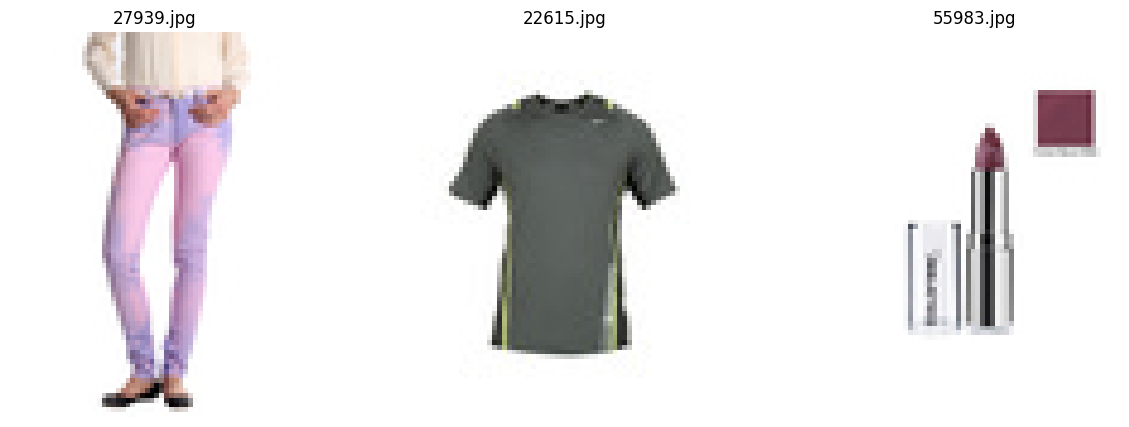

In [5]:
!kaggle datasets download -d paramaggarwal/fashion-product-images-small --unzip

import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

print("\nKẾT QUẢ EDA DATASET 2: FASHION BẢN NHẸ")

# Tìm file CSV và đọc dữ liệu
fashion_csv_paths = glob.glob('**/styles.csv', recursive=True)

if fashion_csv_paths:
    fashion_csv_path = fashion_csv_paths[0]
    df2 = pd.read_csv(fashion_csv_path, on_bad_lines='skip')

    print(f"Tổng số mẫu (ảnh/dòng): {df2.shape[0]}")
    print(f"Tổng số trường dữ liệu (cột): {df2.shape[1]}")
    print("\nVấn đề chất lượng (Số lượng dữ liệu rỗng ở mỗi cột):")
    print(df2.isnull().sum())

    # Load và hiển thị 3 ảnh minh họa
    # phần này tìm kiếm các thư mục con của nó và trả về kết quả là 1 danh sách
    # các đường dẫn đến tất cả các thư mục images và bắt đầu từ phần tử đầu tiên
    img_folders = glob.glob('**/images', recursive=True)
    if img_folders:
        img_folder = img_folders[0]
        # liệt kê tất cả các tệp trong thư mục ảnh vừa tìm được và lấy ra 3 tệp đầu tiên
        sample_imgs = os.listdir(img_folder)[:3]

        print("\nẢnh mẫu:")
        # tạo ra đồ thị và 3 ô con để hiển thị danh sách mẫu 1 hàng 3 cột,
        # figsize = (15, 5) đặt kích thước của toàn bộ vùng đồ thị
        fig, ax = plt.subplots(1, 3, figsize=(15, 5))
        for i, img_name in enumerate(sample_imgs):
        # tạo đường dẫn đến từng tệp gồm đường dẫn thư mục ảnh và tên tệp ảnh
            img_path = os.path.join(img_folder, img_name)
            img = mpimg.imread(img_path)
            ax[i].imshow(img)
            # tắt các trục tọa độ
            ax[i].axis('off')
            ax[i].set_title(img_name)
        plt.show()
    else:
        print("\nKhông tìm thấy thư mục 'images' trong dataset.")
else:
    print("\nKhông tìm thấy file 'styles.csv' trong dataset này. Vui lòng kiểm tra lại đường dẫn hoặc tên file.")


Ô này tải dữ liệu từ kaggle sau đó đếm tổng số lượng ảnh jpg và png, tìm các tệp metadata (json hoặc csv) đọc tệp đầu tiên và in ra thông tin về số dòng, số cột và dữ liệu rỗng. Cuối cùng hiển thị 3 mẫu ảnh ngẫu nhiên.

Dataset URL: https://www.kaggle.com/datasets/hoangkim14/fashion-iq-dataset
License(s): other
100% 630M/630M [00:17<00:00, 37.6MB/s]


KẾT QUẢ EDA DATASET 3: FASHION IQ
Tổng số lượng ảnh tìm thấy: 163263 ảnh

Đã tìm thấy file metadata tại: fashionIQ_dataset/captions/cap.dress.test.json
Tổng số mẫu (dòng): 2024
Các trường dữ liệu (cột): 2

Vấn đề chất lượng (dữ liệu rỗng):
candidate    0
captions     0
dtype: int64


,candidate,captions
0,B007E66YTO,"[ yello and more flowing, short and black]"
1,B007CPAGDW,[sleeveless satin dress gold and black with or...



Ảnh mẫu:


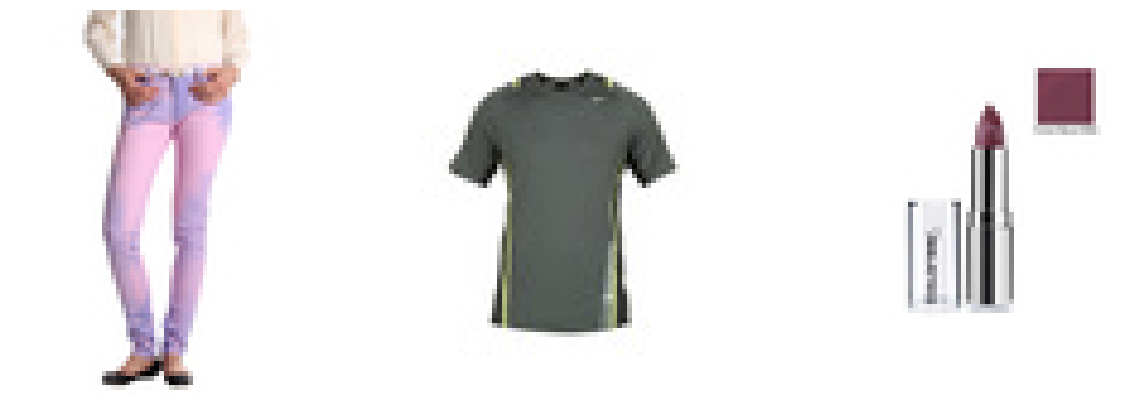

In [6]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Tải và giải nén Dataset 3
!kaggle datasets download -d hoangkim14/fashion-iq-dataset --unzip

print("\nKẾT QUẢ EDA DATASET 3: FASHION IQ")

# Quét đếm ảnh
image_files = glob.glob('**/*.jpg', recursive=True) + glob.glob('**/*.png', recursive=True)
print(f"Tổng số lượng ảnh tìm thấy: {len(image_files)} ảnh")

# Quét tìm file JSON hoặc CSV (vì Fashion IQ thường lưu metadata dạng JSON)
meta_files = glob.glob('**/*.json', recursive=True) + glob.glob('**/*.csv', recursive=True)

if meta_files:
    print(f"\nĐã tìm thấy file metadata tại: {meta_files[0]}")
    # Đọc thử file đầu tiên JSON/CSV
    try:
        if meta_files[0].endswith('.csv'):
            df3 = pd.read_csv(meta_files[0])
        else:
            df3 = pd.read_json(meta_files[0])

        print(f"Tổng số mẫu (dòng): {df3.shape[0]}")
        print(f"Các trường dữ liệu (cột): {df3.shape[1]}")
        print("\nVấn đề chất lượng (dữ liệu rỗng):")
        print(df3.isnull().sum())
        display(df3.head(2))
    except Exception as e:
        print(f"Không thể đọc metadata tự động: {e}")
else:
    print("\nChỉ tìm thấy ảnh, không thấy file metadata.")

# Hiển thị 3 ảnh mẫu
if image_files:
    print("\nẢnh mẫu:")
    fig, ax = plt.subplots(1, min(3, len(image_files)), figsize=(15, 5))
    for i in range(min(3, len(image_files))):
        img = mpimg.imread(image_files[i])
        ax[i].imshow(img)
        ax[i].axis('off')
    plt.show()

Tương tự đém số lượng ảnh jpg, tìm các tệp metadata dạng json, đọc và in ra thông tin tương tự

Dataset URL: https://www.kaggle.com/datasets/silverstone1903/deep-fashion-multimodal
License(s): CC-BY-NC-SA-4.0
100% 1.89G/1.89G [00:51<00:00, 39.3MB/s]


KẾT QUẢ EDA DATASET 4: DEEPFASHION
Tổng số lượng ảnh tìm thấy: 175541 ảnh

Đã tìm thấy file metadata tại: fashionIQ_dataset/captions/cap.dress.test.json
Tổng số mẫu (dòng): 2024
Các trường dữ liệu (cột): 2

Vấn đề chất lượng (dữ liệu rỗng):
candidate    0
captions     0
dtype: int64


,candidate,captions
0,B007E66YTO,"[ yello and more flowing, short and black]"
1,B007CPAGDW,[sleeveless satin dress gold and black with or...



Ảnh mẫu:


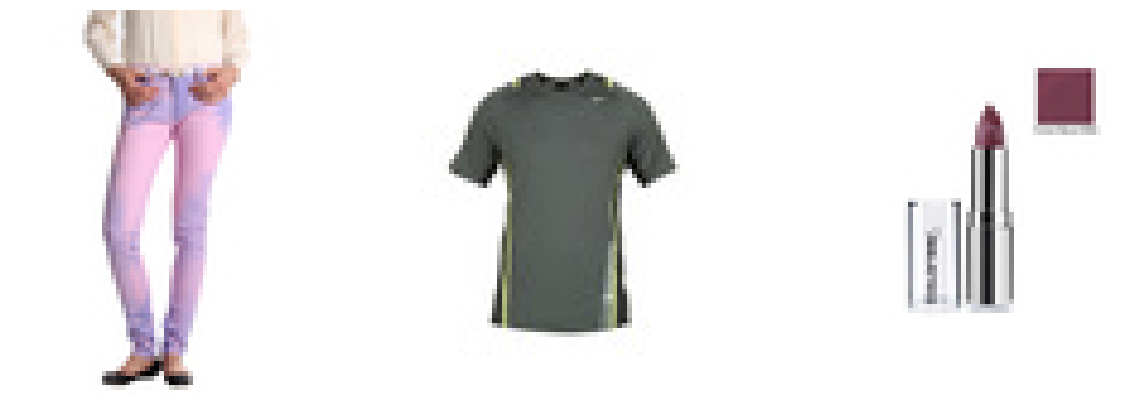

In [7]:
# Tải và giải nén Dataset 4
!kaggle datasets download -d silverstone1903/deep-fashion-multimodal --unzip

print("\nKẾT QUẢ EDA DATASET 4: DEEPFASHION")

image_files_df = glob.glob('**/*.jpg', recursive=True)
print(f"Tổng số lượng ảnh tìm thấy: {len(image_files_df)} ảnh")

# DeepFashion thường lưu metadata dạng JSON hoặc Text
meta_files_df = glob.glob('**/*.json', recursive=True)

if meta_files_df:
    print(f"\nĐã tìm thấy file metadata tại: {meta_files_df[0]}")
    try:
        df4 = pd.read_json(meta_files_df[0])
        print(f"Tổng số mẫu (dòng): {df4.shape[0]}")
        print(f"Các trường dữ liệu (cột): {df4.shape[1]}")
        print("\nVấn đề chất lượng (dữ liệu rỗng):")
        print(df4.isnull().sum())
        display(df4.head(2))
    except:
        print("Đã thấy file metadata nhưng file có cấu trúc lồng nhau phức tạp.")
else:
    print("\nKhông tìm thấy file metadata gốc dạng bảng/JSON chuẩn.")

if image_files_df:
    print("\nẢnh mẫu:")
    fig, ax = plt.subplots(1, min(3, len(image_files_df)), figsize=(15, 5))
    for i in range(min(3, len(image_files_df))):
        img = mpimg.imread(image_files_df[i])
        ax[i].imshow(img)
        ax[i].axis('off')
    plt.show()

Ô này tải 1 bản mirror của bộ dữ liệu do không tải được trực tiếp tử kaggle. Bao gồm đếm tổng số lượng ảnh jpg và png, tìm tệp articles.csv chứa thông tin sản phẩm của H&M và đọc nó vào dataframe sau đó in các thông tin cơ bản như số dòng, cột, chi tiết cột, dữ liệu rỗng và hiển thị 2 dòng dầu tiên. Cuối cùng hiển thị 3 mẫu từ bộ dữ liệu.

Dataset URL: https://www.kaggle.com/datasets/derrickmwiti/hm-personalized-fashion-recommendations
License(s): unknown
100% 709M/709M [00:20<00:00, 37.1MB/s]


KẾT QUẢ EDA DATASET 5: H&M BẢN MIRROR
Tổng số lượng ảnh tìm thấy: 175541 ảnh

Không tìm thấy file articles.csv trong bản này.

Ảnh mẫu H&M:


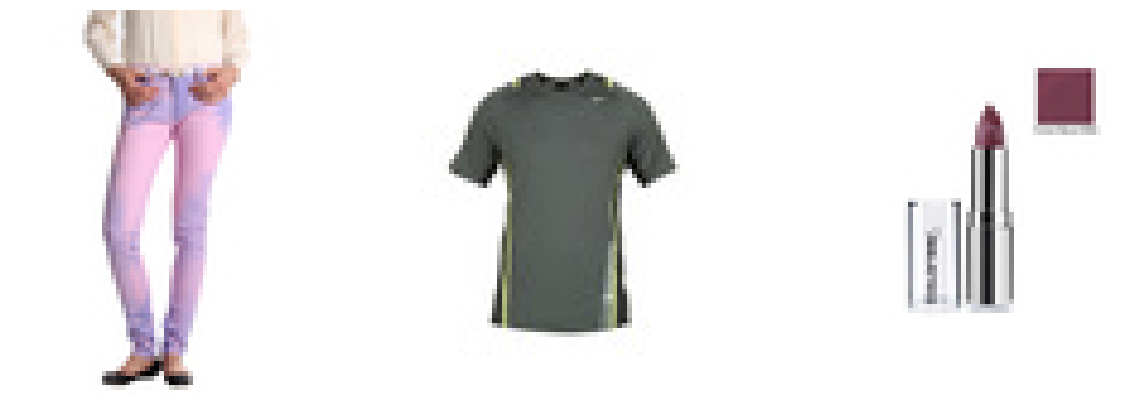

In [8]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Tải bộ H&M từ Public Dataset thay vì Competition
!kaggle datasets download -d derrickmwiti/hm-personalized-fashion-recommendations --unzip

print("\nKẾT QUẢ EDA DATASET 5: H&M BẢN MIRROR")

# Quét ảnh
hm_images = glob.glob('**/*.jpg', recursive=True) + glob.glob('**/*.png', recursive=True)
print(f"Tổng số lượng ảnh tìm thấy: {len(hm_images)} ảnh")

# Quét tìm và đọc file articles.csv chứa thông tin sản phẩm
hm_csv = glob.glob('**/articles.csv', recursive=True)

if hm_csv:
    df_hm = pd.read_csv(hm_csv[0])
    print(f"\nTổng số mẫu (dòng): {df_hm.shape[0]}")
    print(f"Các trường dữ liệu (cột): {df_hm.shape[1]}")
    print("\nChi tiết các trường:")
    print(df_hm.info())
    print("\nVấn đề chất lượng (Dữ liệu rỗng):")
    print(df_hm.isnull().sum())
    display(df_hm.head(2))
else:
    print("\nKhông tìm thấy file articles.csv trong bản này.")

# Hiển thị 3 ảnh mẫu (nếu có)
if hm_images:
    print("\nẢnh mẫu H&M:")
    fig, ax = plt.subplots(1, min(3, len(hm_images)), figsize=(15, 5))
    for i in range(min(3, len(hm_images))):
        img = mpimg.imread(hm_images[i])
        if min(3, len(hm_images)) > 1:
            ax[i].imshow(img)
            ax[i].axis('off')
        else:
            ax.imshow(img)
            ax.axis('off')
    plt.show()